## Import packages and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geneinfo.coords import gene_coords
import geneinfo.plot as gplt
import geneinfo.information as gi
from genome_intervals import interval_collapse
from chrom_windows import window

from geneinfo.genelist import GeneListCollection 
from geneinfo.genelist import GeneList as glist
import geneinfo.ontology as go


In [2]:
LinARs_df = pd.read_csv("../data/adc9507_Data_S1.csv", sep=";", skiprows=2)
LinARs_df = LinARs_df.dropna(axis=1, how="all")
LinARs_df.head()

,Chr,Start,End,LinAR_ID,Nearest_Neighboring_Gene,lncRNA_ID,cCREs_ID,Gene_name,Lineage_name,PhyloP score,P-value,Q-value
0,chr3,82154474,82154736,HLinAR-Rank1,NONE,URS0000EBC6E1_9606,NONE,NONE,Human,"167,07914",0,0
1,chr21,8424934,8425419,HLinAR-Rank2,NONE,URS00019A85AC_9606,NONE,NONE,Human,"97,33254",0,0
2,chr20,63102113,63102273,HLinAR-Rank3*,ENSG00000149658,URS0000EF61E2_9606,EH38E2128905,YTHDF1,Human,"90,33879",0,0
3,chr21,8424387,8424860,HLinAR-Rank4,NONE,URS00019A85AC_9606,NONE,NONE,Human,"88,65024",0,0
4,chr21,8241960,8242395,HLinAR-Rank5,NONE,URS0001A07CFE_9606,NONE,NONE,Human,"81,2051",0,0


## Compartment analysis

### Import file

In [3]:
compartment_df = pd.read_csv("../data/chrX_compartments.csv", sep=",")
compartment_df.head()

,chrom,start,end,E1,compart
0,chrX,0,50000,NaN,B
1,chrX,50000,100000,NaN,B
2,chrX,100000,150000,NaN,B
3,chrX,150000,200000,NaN,B
4,chrX,200000,250000,NaN,B


### Calculate distance between LinARs and compartments on chr X

         LinAR_ID   Chr  Start_LinAR  End_LinAR Lineage_name Compartment  \
0  HLinAR-Rank56*  chrX    138710262  138711758        Human           B   
1   HLinAR-Rank87  chrX    103910029  103910206        Human           B   
2  HLinAR-Rank157  chrX     71910623   71911026        Human           A   
3  HLinAR-Rank220  chrX    139142129  139142405        Human           A   
4  HLinAR-Rank234  chrX    116107686  116108025        Human           B   

   Compartment_start  Compartment_end  Distance_to_compartment_border  
0        138700000.0      138750000.0                           10262  
1        103900000.0      103950000.0                           10029  
2         71900000.0       71950000.0                           10623  
3        139100000.0      139150000.0                            7595  
4        116100000.0      116150000.0                            7686  


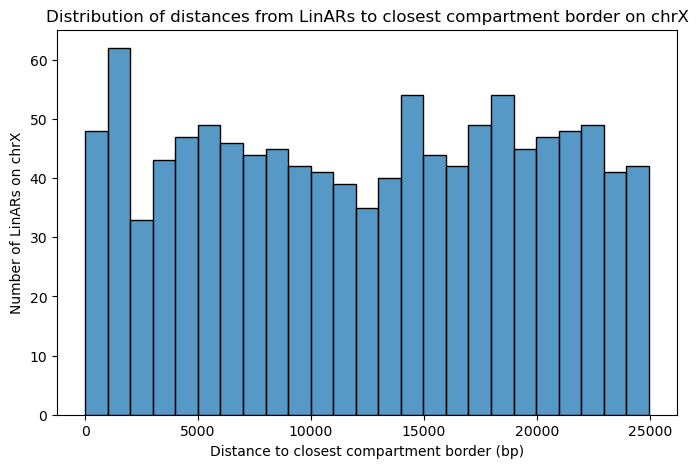

In [5]:
# For each LinAR, find all compartments on the same chromosome, calculate the distance between that LinAR and each compartment, pick row with smallest distance, and store that in a new dataframe

# Keep only LinARs on chromosome X
apes = ["Human", "Pan troglodytes", "Pan paniscus", "Gorilla gorilla", "Pongo abelii", "Pongo pygmaeus", "Nomascus siki", "Symphalangus syndactylus", "Hoolock leuconedys", "Hylobates pileatus", "Homininae", "Ponginae", "Hylobatidae", "Hominidae", "Hominoidea"]
ape_LinARs_df = LinARs_df[LinARs_df["Lineage_name"].isin(apes)].dropna(subset=["Gene_name"])
ape_LinARs_chrX = ape_LinARs_df[ape_LinARs_df["Chr"] == "chrX"].copy()

# Keep only compartmetns on chromosome X
compartment_chrX = compartment_df[compartment_df["chrom"] == "chrX"].copy()


results = []

for i, LinAR in ape_LinARs_chrX.iterrows():
    chrom = str(LinAR['Chr'])
    LinAR_start = LinAR['Start']
    LinAR_end = LinAR['End']

    # Find the compartment containing the LinAR
    containing_compartment = compartment_chrX[
        (LinAR_start >= compartment_chrX['start']) & 
        (LinAR_end <= compartment_chrX['end'])
    ]

    if not containing_compartment.empty:
        # LinAR fully contained: calculate absolute distance to nearest border
        compartment = containing_compartment.iloc[0]
        dist_to_start = abs(LinAR_start - compartment["start"])
        dist_to_end = abs(LinAR_end - compartment["end"])
        distance_to_border = min(dist_to_start, dist_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]
    else:
        # LinAR overlaps borders or outside compartments
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan

    
    results.append({
        'LinAR_ID': LinAR['LinAR_ID'],
        'Chr': chrom,
        'Start_LinAR': LinAR_start,
        'End_LinAR': LinAR_end,
        'Lineage_name': LinAR.get('Lineage_name'),
        'Compartment':  compartment_type,
        'Compartment_start': compartment_start,
        'Compartment_end': compartment_end,
        'Distance_to_compartment_border': distance_to_border
    })


linar_compartment_border_distances = pd.DataFrame(results)
print(linar_compartment_border_distances.head())


# Plot distribution of absolute distances with Seaborn
plt.figure(figsize=(8,5))
sns.histplot(
    data=linar_compartment_border_distances, 
    x='Distance_to_compartment_border', 
    bins=25, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Number of LinARs on chrX")
plt.title("Distribution of distances from LinARs to closest compartment border on chrX")
plt.show()




Compartment
A          0.709477
B          0.284322
Overlap    0.006200
Name: count, dtype: float64


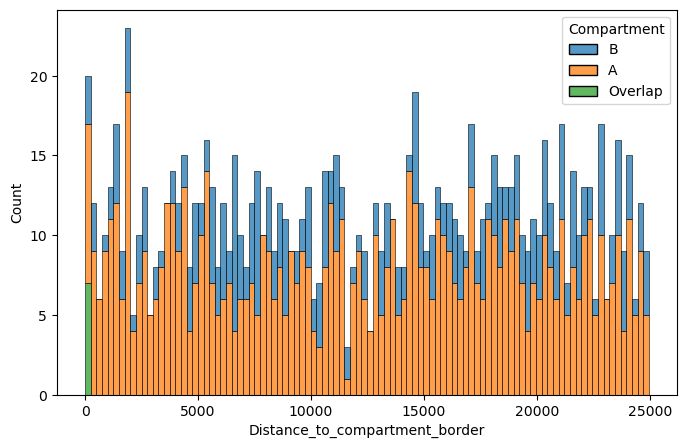

In [ ]:
# Color by compartment
plt.figure(figsize=(8,5))
sns.histplot(
    data=linar_compartment_border_distances, 
    x='Distance_to_compartment_border', 
    hue='Compartment', 
    bins=100, 
    multiple='stack',
    edgecolor='black'
)

# Calculate the proportion of LinARs in A and B compartments
compartment_counts = linar_compartment_border_distances['Compartment'].value_counts()
total_counts = compartment_counts.sum()
compartment_proportions = compartment_counts / total_counts
print(compartment_proportions)


### Is the distances closer than expected? 

         LinAR_ID   Chr  Start_LinAR  End_LinAR Lineage_name Compartment  \
0  HLinAR-Rank56*  chrX      5581745    5583241        Human           A   
1   HLinAR-Rank87  chrX     52653288   52653465        Human           B   
2  HLinAR-Rank157  chrX    132031195  132031598        Human           A   
3  HLinAR-Rank220  chrX     73080846   73081122        Human           A   
4  HLinAR-Rank234  chrX    155276493  155276832        Human           A   

   Compartment_start  Compartment_end  Distance_to_compartment_border  
0          5550000.0        5600000.0                           16759  
1         52650000.0       52700000.0                            3288  
2        132000000.0      132050000.0                           18402  
3         73050000.0       73100000.0                           18878  
4        155250000.0      155300000.0                           23168  


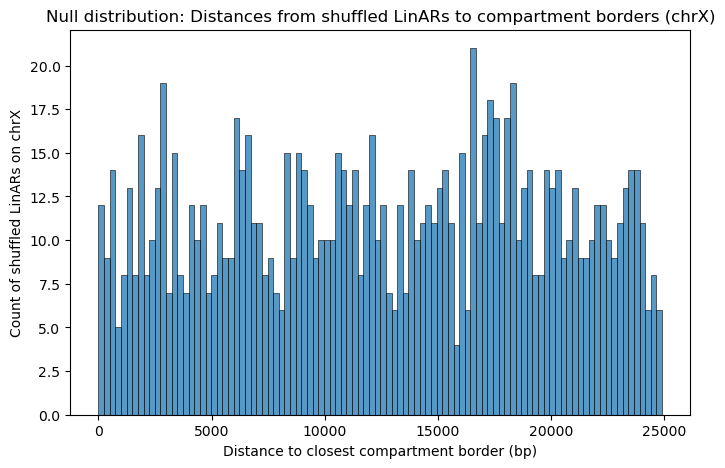

In [6]:
x_chrom_length = 156040895  

# Shuffle LinAR positions on chrX
shuffled_LinARs = []
for i, LinAR in ape_LinARs_chrX.iterrows():
    length = LinAR["End"] - LinAR["Start"]
    random_start = np.random.randint(0, x_chrom_length - length) 
    random_end = random_start + length
    
    shuffled_LinARs.append({
        "LinAR_ID": LinAR["LinAR_ID"],
        "Chr": "chrX",
        "Start": random_start,
        "End": random_end,
        "Lineage_name": LinAR.get("Lineage_name")
    })

shuffled_linars_df = pd.DataFrame(shuffled_LinARs)

# Calculate distances for shuffled LinARs 
shuffled_results = []

for i, LinAR in shuffled_linars_df.iterrows():
    LinAR_start = LinAR["Start"]
    LinAR_end = LinAR["End"]

    # Find compartment containing the shuffled LinAR
    containing_compartment = compartment_chrX[
        (LinAR_start >= compartment_chrX["start"]) &
        (LinAR_end <= compartment_chrX["end"])
    ]

    if not containing_compartment.empty:
        # Fully contained — calculate distance to nearest border
        compartment = containing_compartment.iloc[0]
        dist_to_start = abs(LinAR_start - compartment["start"])
        dist_to_end = abs(LinAR_end - compartment["end"])
        distance_to_border = min(dist_to_start, dist_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]
    else:
        # Overlaps border or between compartments
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan

    shuffled_results.append({
        "LinAR_ID": LinAR["LinAR_ID"],
        "Chr": LinAR["Chr"],
        "Start_LinAR": LinAR_start,
        "End_LinAR": LinAR_end,
        "Lineage_name": LinAR.get("Lineage_name"),
        "Compartment": compartment_type,
        "Compartment_start": compartment_start,
        "Compartment_end": compartment_end,
        "Distance_to_compartment_border": distance_to_border
    })

# Convert results to df
shuffled_linar_compartment_distances = pd.DataFrame(shuffled_results)
print(shuffled_linar_compartment_distances.head())

plt.figure(figsize=(8,5))
sns.histplot(
    data=shuffled_linar_compartment_distances,
    x="Distance_to_compartment_border",
    bins=100,
    kde=False,
    edgecolor="black"
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count of shuffled LinARs on chrX")
plt.title("Null distribution: Distances from shuffled LinARs to compartment borders (chrX)")
plt.show()


In [ ]:
compartment_chrX = compartment_chrX.copy()
compartment_chrX['length'] = compartment_chrX['end'] - compartment_chrX['start']
print(compartment_chrX['length'].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]))


count     3121.000000
mean     49997.082666
std        162.979532
min      40895.000000
1%       50000.000000
5%       50000.000000
25%      50000.000000
50%      50000.000000
75%      50000.000000
95%      50000.000000
99%      50000.000000
max      50000.000000
Name: length, dtype: float64


count    1129.000000
mean      264.405669
std       225.791233
min        22.000000
25%       107.000000
50%       200.000000
75%       339.000000
max      1496.000000
Name: length, dtype: float64


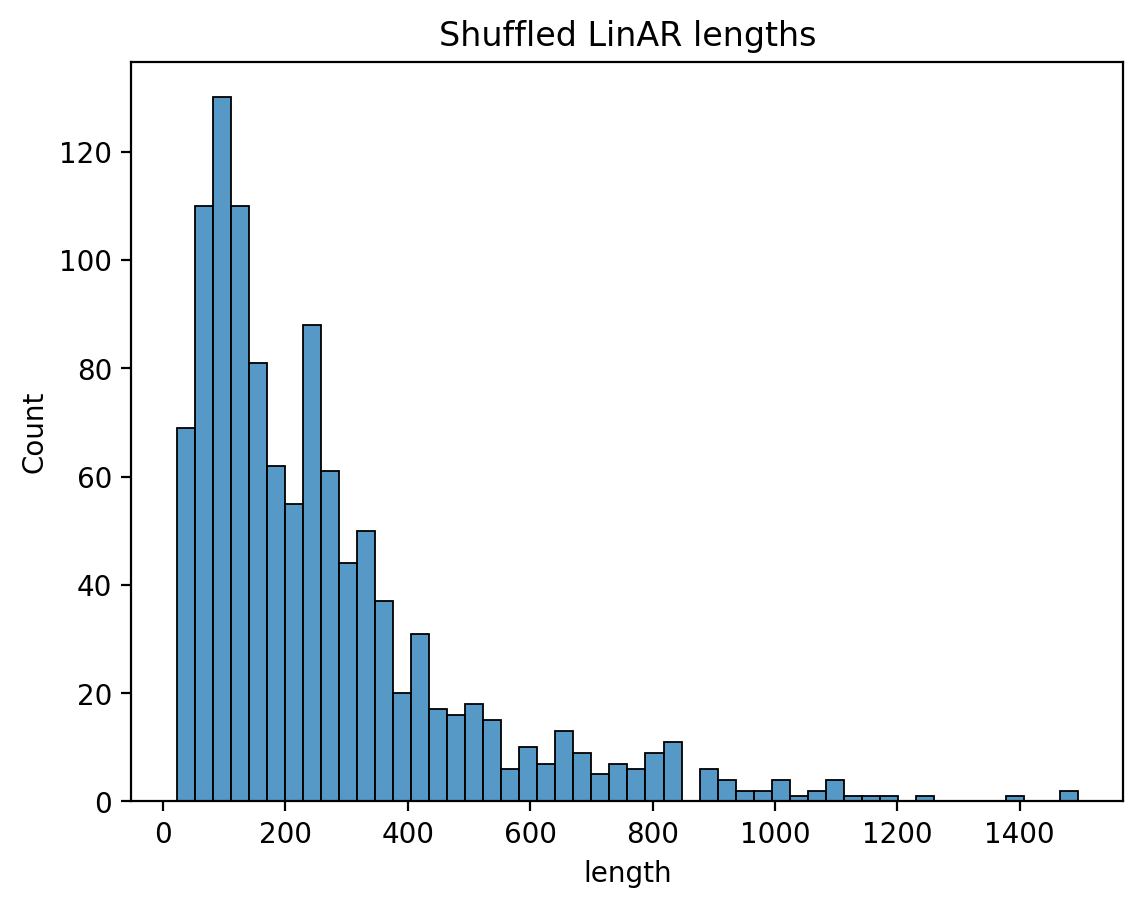

In [ ]:
shuffled_linars_df['length'] = shuffled_linars_df['End'] - shuffled_linars_df['Start']
print(shuffled_linars_df['length'].describe())
sns.histplot(shuffled_linars_df['length'], bins=50)
plt.title('Shuffled LinAR lengths')
plt.show()


In [ ]:
# Statistical test (Kolmogorov-Smirnov test) to compare real vs shuffled distance distributions
# Are each distributions significantly different?

from scipy.stats import ks_2samp

real = linar_compartment_border_distances["Distance_to_compartment_border"].abs()
shuffled = shuffled_linar_compartment_distances["Distance_to_compartment_border"].abs()

ks_stat, p_val = ks_2samp(real, shuffled)
print(f"KS statistic = {ks_stat:.3f}, p-value = {p_val:.3e}")


KS statistic = 0.024, p-value = 5.916e-01


### Neuron gene distance to border

         LinAR_ID   Chr  Start_LinAR  End_LinAR Lineage_name Compartment  \
0  HLinAR-Rank56*  chrX    138710262  138711758        Human           B   
1   HLinAR-Rank87  chrX    103910029  103910206        Human           B   
2  HLinAR-Rank157  chrX     71910623   71911026        Human           A   
3  HLinAR-Rank220  chrX    139142129  139142405        Human           A   
4  HLinAR-Rank326  chrX     32928973   32929388        Human           B   

   Compartment_start  Compartment_end  Distance_to_compartment_border  
0        138700000.0      138750000.0                           10262  
1        103900000.0      103950000.0                           10029  
2         71900000.0       71950000.0                           10623  
3        139100000.0      139150000.0                            7595  
4         32900000.0       32950000.0                           20612  


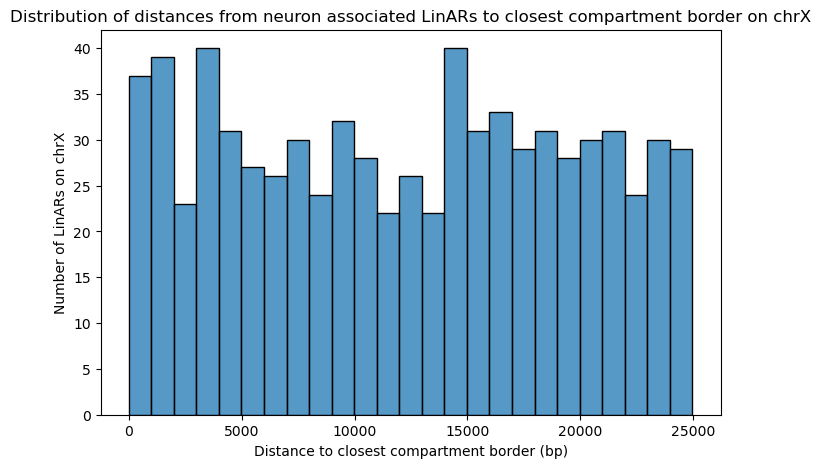

In [7]:
# For each LinAR, find all compartments on the same chromosome, calculate the distance between that LinAR and each compartment, pick row with smallest distance, and store that in a new dataframe

# Keep only LinARs on chromosome X
ape_LinARs_chrX = ape_LinARs_df[ape_LinARs_df["Chr"] == "chrX"].copy()

# Keep only compartmetns on chromosome X
compartment_chrX = compartment_df[compartment_df["chrom"] == "chrX"].copy()

# Filter ape_LinARs_chrX to only contain LinARs associated with neuron_genes genes 
gene_list = GeneListCollection( "../data/cecilie_gen_lister.yaml") 
neuron_genes = gene_list.get('neuron_genes') 
linars_neuron_df = ape_LinARs_chrX[ape_LinARs_chrX["Gene_name"].isin(neuron_genes)] 


results = []

for i, LinAR in linars_neuron_df.iterrows():
    chrom = str(LinAR['Chr'])
    LinAR_start = LinAR['Start']
    LinAR_end = LinAR['End']

    # Find the compartment containing the LinAR
    containing_compartment = compartment_chrX[
        (LinAR_start >= compartment_chrX['start']) & 
        (LinAR_end <= compartment_chrX['end'])
    ]

    if not containing_compartment.empty:
        # LinAR fully contained: calculate absolute distance to nearest border
        compartment = containing_compartment.iloc[0]
        dist_to_start = abs(LinAR_start - compartment["start"])
        dist_to_end = abs(LinAR_end - compartment["end"])
        distance_to_border = min(dist_to_start, dist_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]
    else:
        # LinAR overlaps borders or outside compartments
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan

    
    results.append({
        'LinAR_ID': LinAR['LinAR_ID'],
        'Chr': chrom,
        'Start_LinAR': LinAR_start,
        'End_LinAR': LinAR_end,
        'Lineage_name': LinAR.get('Lineage_name'),
        'Compartment':  compartment_type,
        'Compartment_start': compartment_start,
        'Compartment_end': compartment_end,
        'Distance_to_compartment_border': distance_to_border
    })


linar_compartment_border_distances = pd.DataFrame(results)
print(linar_compartment_border_distances.head())


# Plot distribution of absolute distances with Seaborn
plt.figure(figsize=(8,5))
sns.histplot(
    data=linar_compartment_border_distances, 
    x='Distance_to_compartment_border', 
    bins=25, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Number of LinARs on chrX")
plt.title("Distribution of distances from neuron associated LinARs to closest compartment border on chrX")
plt.show()




### Neuron gene distance to border (include only each gene once (one LinAR for each gene))

     LinAR_ID   Chr  Start_LinAR  End_LinAR              Lineage_name  \
349   Rank188  chrX     41349917   41350204             Nomascus siki   
528  Rank2075  chrX     44399974   44400161             Nomascus siki   
650   Rank123  chrX     24149928   24150006  Symphalangus syndactylus   
141   Rank866  chrX     72099862   72100010        Hylobates pileatus   
458  Rank1239  chrX     97299757   97300230             Nomascus siki   

    Gene_name Compartment  Compartment_start  Compartment_end  \
349     DDX3X     Overlap                NaN              NaN   
528     EFHC2     Overlap                NaN              NaN   
650       ZFX     Overlap                NaN              NaN   
141     NHSL2     Overlap                NaN              NaN   
458    DIAPH2     Overlap                NaN              NaN   

     Distance_to_compartment_border  
349                               0  
528                               0  
650                               0  
141               

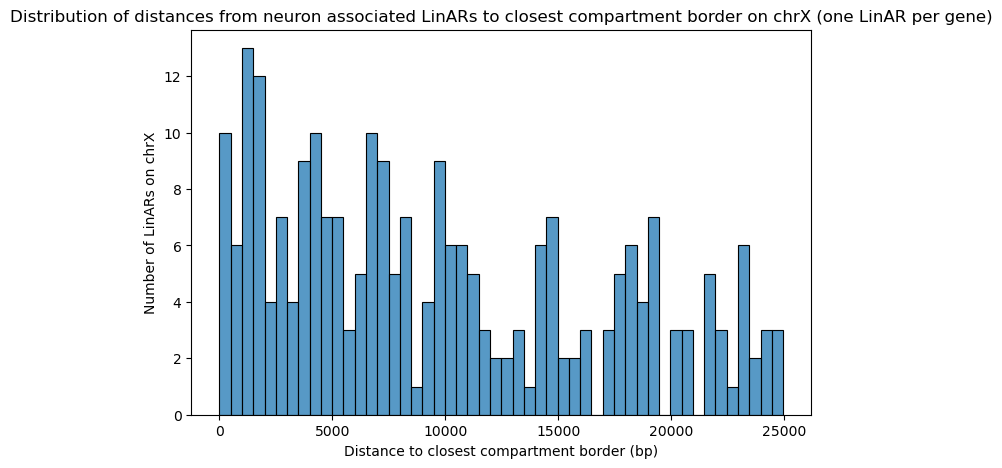

In [8]:
# For each LinAR, find all compartments on the same chromosome, calculate the distance between that LinAR and each compartment, pick row with smallest distance, and store that in a new dataframe

# Keep only LinARs on chromosome X
ape_LinARs_chrX = ape_LinARs_df[ape_LinARs_df["Chr"] == "chrX"].copy()

# Keep only compartmetns on chromosome X
compartment_chrX = compartment_df[compartment_df["chrom"] == "chrX"].copy()

# Filter ape_LinARs_chrX to only contain LinARs associated with neuron_genes genes 
gene_list = GeneListCollection( "../data/cecilie_gen_lister.yaml") 
neuron_genes = gene_list.get('neuron_genes') 
linars_neuron_df = ape_LinARs_chrX[ape_LinARs_chrX["Gene_name"].isin(neuron_genes)] 


results = []

for i, LinAR in linars_neuron_df.iterrows():
    chrom = str(LinAR['Chr'])
    LinAR_start = LinAR['Start']
    LinAR_end = LinAR['End']

    # Find the compartment containing the LinAR
    containing_compartment = compartment_chrX[
        (LinAR_start >= compartment_chrX['start']) & 
        (LinAR_end <= compartment_chrX['end'])
    ]

    if not containing_compartment.empty:
        # LinAR fully contained: calculate absolute distance to nearest border
        compartment = containing_compartment.iloc[0]
        dist_to_start = abs(LinAR_start - compartment["start"])
        dist_to_end = abs(LinAR_end - compartment["end"])
        distance_to_border = min(dist_to_start, dist_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]
    else:
        # LinAR overlaps borders or outside compartments
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan

    
    results.append({
        'LinAR_ID': LinAR['LinAR_ID'],
        'Chr': chrom,
        'Start_LinAR': LinAR_start,
        'End_LinAR': LinAR_end,
        'Lineage_name': LinAR.get('Lineage_name'),
        'Gene_name': LinAR['Gene_name'],
        'Compartment':  compartment_type,
        'Compartment_start': compartment_start,
        'Compartment_end': compartment_end,
        'Distance_to_compartment_border': distance_to_border
    })


linar_compartment_border_distances = pd.DataFrame(results)

# Keep only the LinAR with the shortest distance per gene
linar_closest_per_gene = (
    linar_compartment_border_distances
    .sort_values("Distance_to_compartment_border")
    .drop_duplicates(subset="Gene_name", keep="first")
)

print(linar_closest_per_gene.head())

# Plot distribution of absolute distances with Seaborn
plt.figure(figsize=(8,5))
sns.histplot(
    data=linar_closest_per_gene, 
    x='Distance_to_compartment_border', 
    bins=50, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Number of LinARs on chrX")
plt.title("Distribution of distances from neuron associated LinARs to closest compartment border on chrX (one LinAR per gene)")
plt.show()




### Spermatid gene distance to border

   LinAR_ID   Chr  Start_LinAR  End_LinAR        Lineage_name Compartment  \
0   Rank274  chrX      2852811    2852997  Hylobates pileatus           A   
1   Rank441  chrX      2853528    2853637  Hylobates pileatus           A   
2  Rank1099  chrX      5890030    5890143  Hylobates pileatus           A   
3   Rank631  chrX      5890281    5890412  Hylobates pileatus           A   
4   Rank443  chrX      7001766    7001876           Hominidae           A   

   Compartment_start  Compartment_end  Distance_to_compartment_border  
0          2850000.0        2900000.0                            2811  
1          2850000.0        2900000.0                            3528  
2          5850000.0        5900000.0                            9857  
3          5850000.0        5900000.0                            9588  
4          7000000.0        7050000.0                            1766  


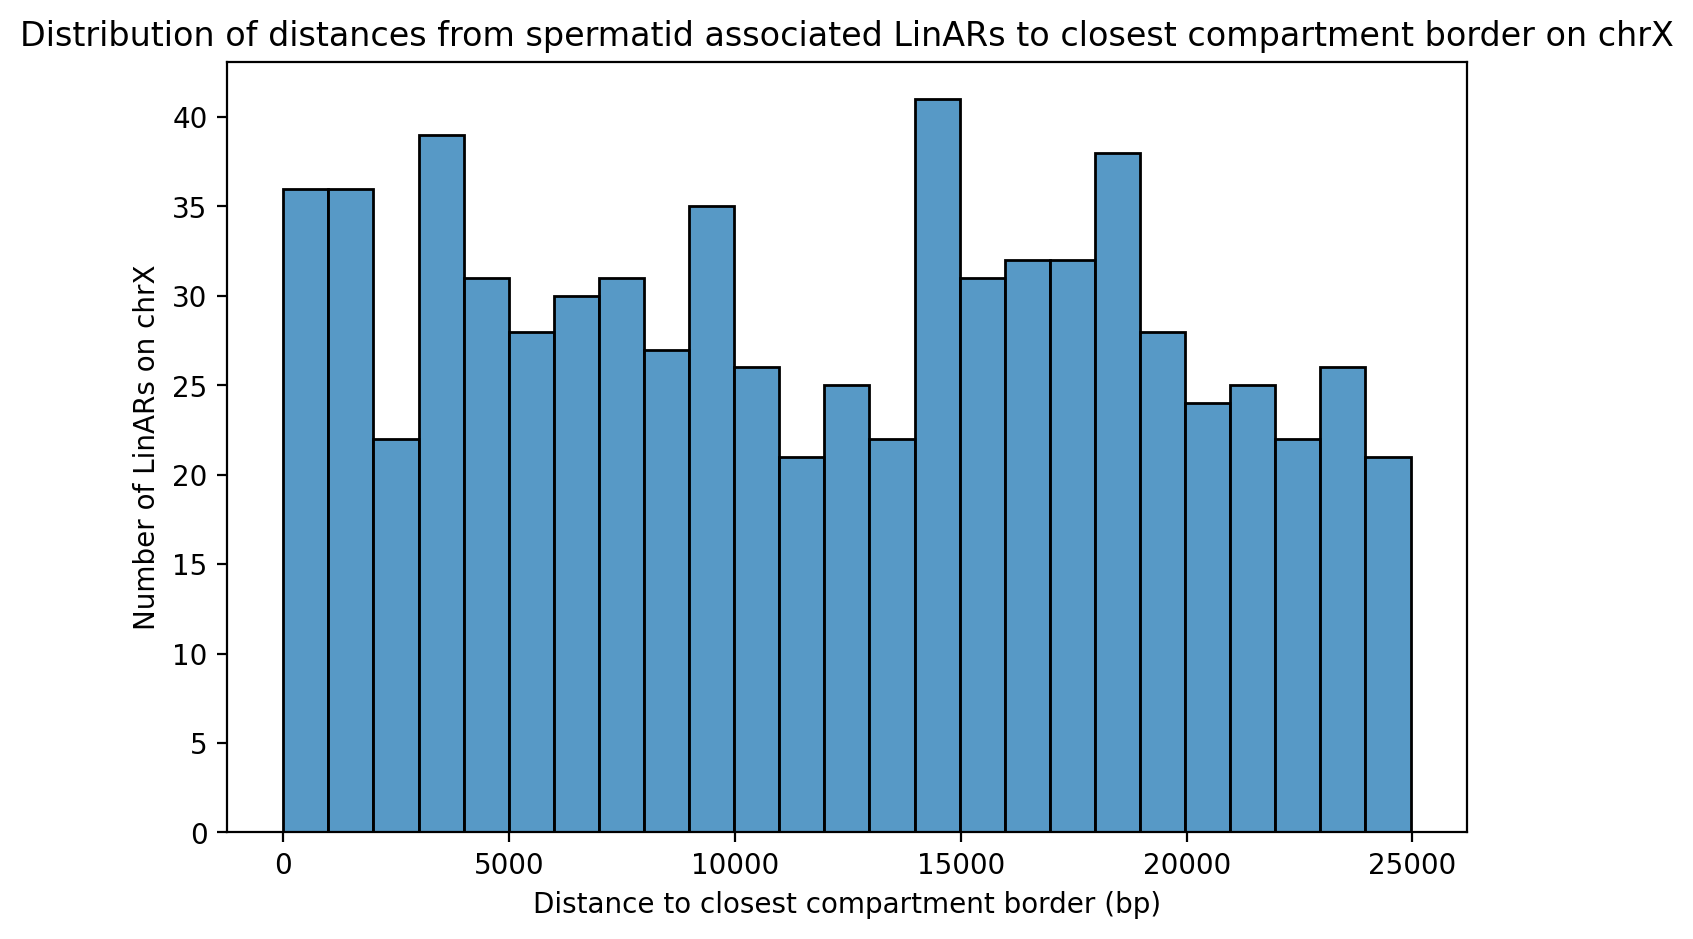

In [ ]:
# For each LinAR, find all compartments on the same chromosome, calculate the distance between that LinAR and each compartment, pick row with smallest distance, and store that in a new dataframe

# Keep only LinARs on chromosome X
ape_LinARs_chrX = ape_LinARs_df[ape_LinARs_df["Chr"] == "chrX"].copy()

# Keep only compartmetns on chromosome X
compartment_chrX = compartment_df[compartment_df["chrom"] == "chrX"].copy()

# Filter ape_LinARs_chrX to only contain LinARs associated with human_spermatid_expressed_genes genes 
gene_list = GeneListCollection( "../data/cecilie_gen_lister.yaml") 
human_spermatid_expressed_genes = gene_list.get('human_spermatid_expressed_genes') 
linars_spermatid_df = ape_LinARs_chrX[ape_LinARs_chrX["Gene_name"].isin(human_spermatid_expressed_genes)] 


results = []

for i, LinAR in linars_spermatid_df.iterrows():
    chrom = str(LinAR['Chr'])
    LinAR_start = LinAR['Start']
    LinAR_end = LinAR['End']

    # Find the compartment containing the LinAR
    containing_compartment = compartment_chrX[
        (LinAR_start >= compartment_chrX['start']) & 
        (LinAR_end <= compartment_chrX['end'])
    ]

    if not containing_compartment.empty:
        # LinAR fully contained: calculate absolute distance to nearest border
        compartment = containing_compartment.iloc[0]
        dist_to_start = abs(LinAR_start - compartment["start"])
        dist_to_end = abs(LinAR_end - compartment["end"])
        distance_to_border = min(dist_to_start, dist_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]
    else:
        # LinAR overlaps borders or outside compartments
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan

    
    results.append({
        'LinAR_ID': LinAR['LinAR_ID'],
        'Chr': chrom,
        'Start_LinAR': LinAR_start,
        'End_LinAR': LinAR_end,
        'Lineage_name': LinAR.get('Lineage_name'),
        'Compartment':  compartment_type,
        'Compartment_start': compartment_start,
        'Compartment_end': compartment_end,
        'Distance_to_compartment_border': distance_to_border
    })


linar_compartment_border_distances = pd.DataFrame(results)
print(linar_compartment_border_distances.head())


# Plot distribution of absolute distances with Seaborn
plt.figure(figsize=(8,5))
sns.histplot(
    data=linar_compartment_border_distances, 
    x='Distance_to_compartment_border', 
    bins=25, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Number of LinARs on chrX")
plt.title("Distribution of distances from spermatid associated LinARs to closest compartment border on chrX")
plt.show()




### Spermatid gene distance to border (one LinAR per gene)

     LinAR_ID   Chr  Start_LinAR  End_LinAR              Lineage_name  \
251  Rank2075  chrX     44399974   44400161             Nomascus siki   
210   Rank113  chrX     41349917   41350204        Hylobates pileatus   
482  Rank1239  chrX     97299757   97300230             Nomascus siki   
453   Rank866  chrX     72099862   72100010        Hylobates pileatus   
131   Rank123  chrX     24149928   24150006  Symphalangus syndactylus   

    Gene_name Compartment  Compartment_start  Compartment_end  \
251     EFHC2     Overlap                NaN              NaN   
210     DDX3X     Overlap                NaN              NaN   
482    DIAPH2     Overlap                NaN              NaN   
453     NHSL2     Overlap                NaN              NaN   
131       ZFX     Overlap                NaN              NaN   

     Distance_to_compartment_border  
251                               0  
210                               0  
482                               0  
453               

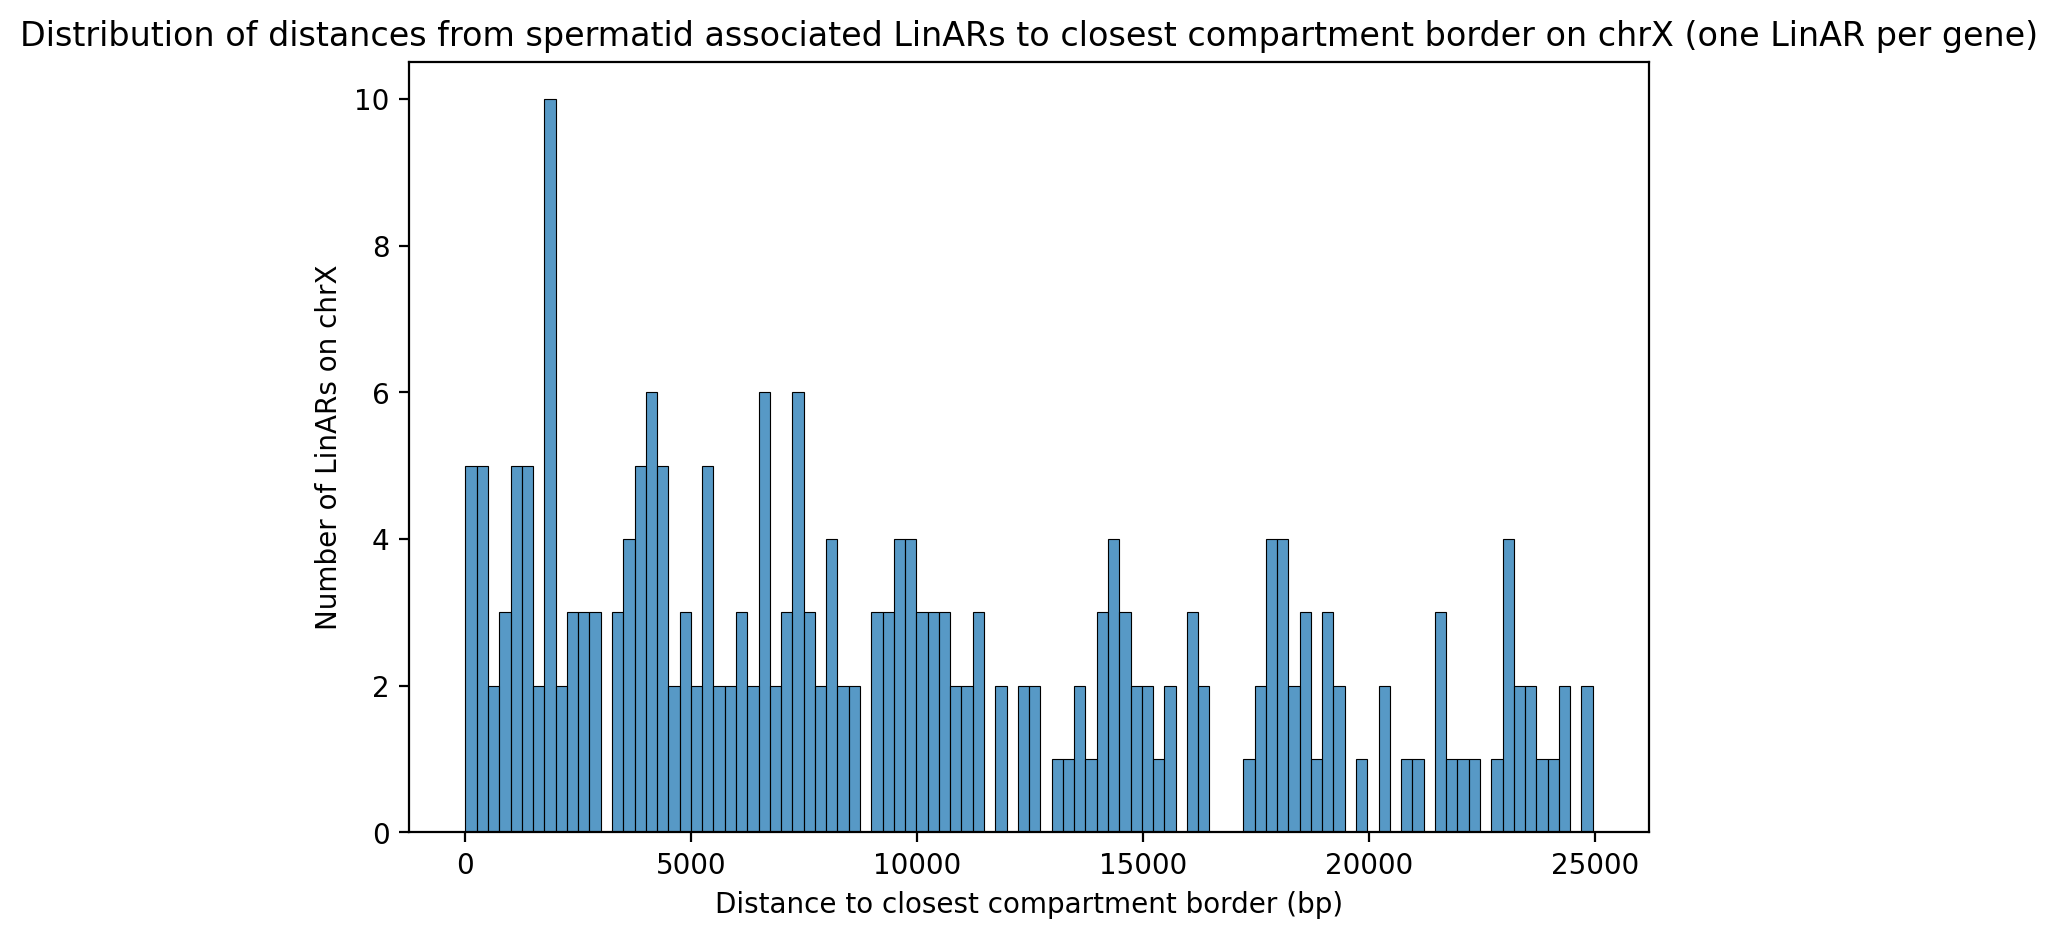

In [ ]:
# For each LinAR, find all compartments on the same chromosome, calculate the distance between that LinAR and each compartment, pick row with smallest distance, and store that in a new dataframe

# Keep only LinARs on chromosome X
ape_LinARs_chrX = ape_LinARs_df[ape_LinARs_df["Chr"] == "chrX"].copy()

# Keep only compartmetns on chromosome X
compartment_chrX = compartment_df[compartment_df["chrom"] == "chrX"].copy()

# Filter ape_LinARs_chrX to only contain LinARs associated with human_spermatid_expressed_genes genes 
gene_list = GeneListCollection( "../data/cecilie_gen_lister.yaml") 
human_spermatid_expressed_genes = gene_list.get('human_spermatid_expressed_genes') 
linars_spermatid_df = ape_LinARs_chrX[ape_LinARs_chrX["Gene_name"].isin(human_spermatid_expressed_genes)] 


results = []

for i, LinAR in linars_spermatid_df.iterrows():
    chrom = str(LinAR['Chr'])
    LinAR_start = LinAR['Start']
    LinAR_end = LinAR['End']

    # Find the compartment containing the LinAR
    containing_compartment = compartment_chrX[
        (LinAR_start >= compartment_chrX['start']) & 
        (LinAR_end <= compartment_chrX['end'])
    ]

    if not containing_compartment.empty:
        # LinAR fully contained: calculate absolute distance to nearest border
        compartment = containing_compartment.iloc[0]
        dist_to_start = abs(LinAR_start - compartment["start"])
        dist_to_end = abs(LinAR_end - compartment["end"])
        distance_to_border = min(dist_to_start, dist_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]
    else:
        # LinAR overlaps borders or outside compartments
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan

    
    results.append({
        'LinAR_ID': LinAR['LinAR_ID'],
        'Chr': chrom,
        'Start_LinAR': LinAR_start,
        'End_LinAR': LinAR_end,
        'Lineage_name': LinAR.get('Lineage_name'),
        'Gene_name': LinAR['Gene_name'],
        'Compartment':  compartment_type,
        'Compartment_start': compartment_start,
        'Compartment_end': compartment_end,
        'Distance_to_compartment_border': distance_to_border
    })


linar_compartment_border_distances = pd.DataFrame(results)

# Keep only the LinAR with the shortest distance per gene
linar_closest_per_gene = (
    linar_compartment_border_distances
    .sort_values("Distance_to_compartment_border")
    .drop_duplicates(subset="Gene_name", keep="first")
)

print(linar_closest_per_gene.head())



# Plot distribution of absolute distances with Seaborn
plt.figure(figsize=(8,5))
sns.histplot(
    data=linar_closest_per_gene, 
    x='Distance_to_compartment_border', 
    bins=100, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Number of LinARs on chrX")
plt.title("Distribution of distances from spermatid associated LinARs to closest compartment border on chrX (one LinAR per gene)")
plt.show()




In [ ]:
linar_compartment_border_distances

,LinAR_ID,Chr,Start_LinAR,End_LinAR,Lineage_name,Gene_name,Compartment,Compartment_start,Compartment_end,Distance_to_compartment_border
0,Rank274,chrX,2852811,2852997,Hylobates pileatus,GYG2,A,2850000.0,2900000.0,2811
1,Rank441,chrX,2853528,2853637,Hylobates pileatus,GYG2,A,2850000.0,2900000.0,3528
2,Rank1099,chrX,5890030,5890143,Hylobates pileatus,NLGN4X,A,5850000.0,5900000.0,9857
3,Rank631,chrX,5890281,5890412,Hylobates pileatus,NLGN4X,A,5850000.0,5900000.0,9588
4,Rank443,chrX,7001766,7001876,Hominidae,PUDP,A,7000000.0,7050000.0,1766
...,...,...,...,...,...,...,...,...,...,...
724,Rank442,chrX,155290197,155290334,Symphalangus syndactylus,CLIC2,A,155250000.0,155300000.0,9666
725,Rank468,chrX,155290556,155290897,Gorilla gorilla,CLIC2,A,155250000.0,155300000.0,9103
726,Rank264,chrX,155290556,155290897,Symphalangus syndactylus,CLIC2,A,155250000.0,155300000.0,9103
727,Rank660,chrX,155292112,155292229,Symphalangus syndactylus,CLIC2,A,155250000.0,155300000.0,7771


### cDEG gene distance to border

  Gene_name  LinAR_ID   Chr  Start_LinAR  End_LinAR        Lineage_name  \
0    CFAP47   Rank435  chrX     36090444   36090715  Hylobates pileatus   
1    CFAP47   Rank770  chrX     36218057   36218194  Hoolock leuconedys   
2     DDX3X  Rank1217  chrX     41314363   41314480       Nomascus siki   
3     DDX3X   Rank316  chrX     41348284   41348459  Hylobates pileatus   
4     DDX3X   Rank433  chrX     41348482   41348646  Hylobates pileatus   

  Compartment  Compartment_start  Compartment_end  \
0           B         36050000.0       36100000.0   
1           B         36200000.0       36250000.0   
2           A         41300000.0       41350000.0   
3           A         41300000.0       41350000.0   
4           A         41300000.0       41350000.0   

   Distance_to_compartment_border  
0                            9285  
1                           18057  
2                           14363  
3                            1541  
4                            1354  


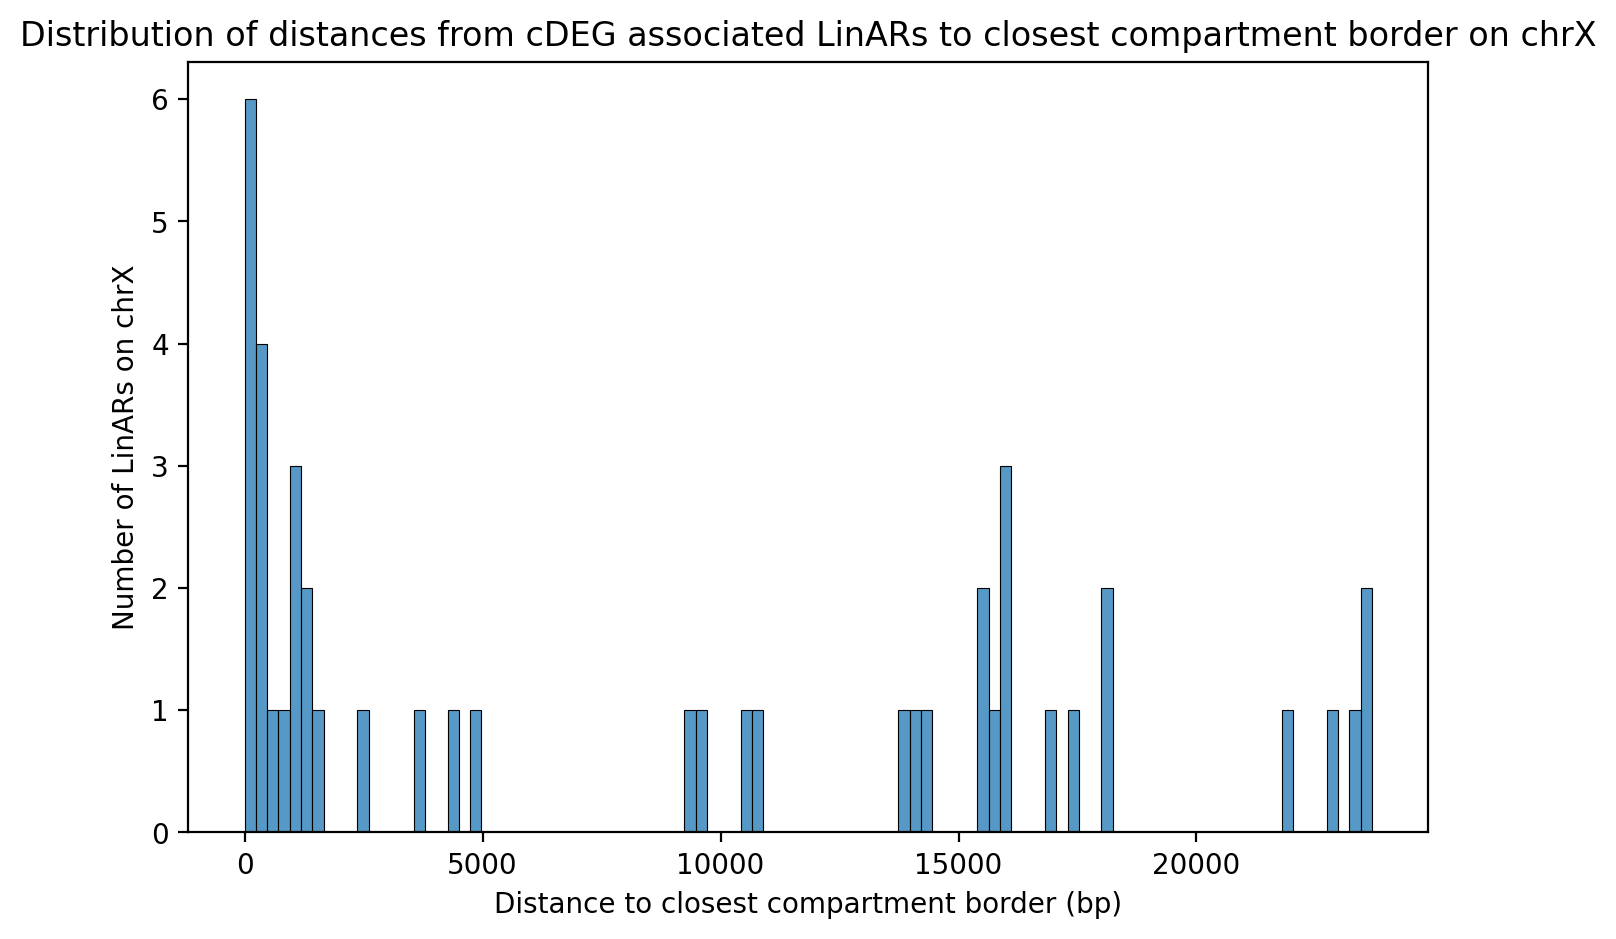

In [ ]:
# For each LinAR, find all compartments on the same chromosome, calculate the distance between that LinAR and each compartment, pick row with smallest distance, and store that in a new dataframe

# Keep only LinARs on chromosome X
ape_LinARs_chrX = ape_LinARs_df[ape_LinARs_df["Chr"] == "chrX"].copy()

# Keep only compartments on chromosome X
compartment_chrX = compartment_df[compartment_df["chrom"] == "chrX"].copy()

# Filter ape_LinARs_chrX to only contain LinARs associated with cDEG_human genes 
gene_list = GeneListCollection( "../data/cecilie_gen_lister.yaml") 
cDEG_human = gene_list.get('cDEG_human') 
linars_cDEG_df = ape_LinARs_chrX[ape_LinARs_chrX["Gene_name"].isin(cDEG_human)] 


results = []

for i, LinAR in linars_cDEG_df.iterrows():
    chrom = str(LinAR['Chr'])
    LinAR_start = LinAR['Start']
    LinAR_end = LinAR['End']

    # Find the compartment containing the LinAR
    containing_compartment = compartment_chrX[
        (LinAR_start >= compartment_chrX['start']) & 
        (LinAR_end <= compartment_chrX['end'])
    ]

    if not containing_compartment.empty:
        # LinAR fully contained: calculate absolute distance to nearest border
        compartment = containing_compartment.iloc[0]
        dist_to_start = abs(LinAR_start - compartment["start"])
        dist_to_end = abs(LinAR_end - compartment["end"])
        distance_to_border = min(dist_to_start, dist_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]
    else:
        # LinAR overlaps borders or outside compartments
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan

    
    results.append({
        'Gene_name': LinAR['Gene_name'],
        'LinAR_ID': LinAR['LinAR_ID'],
        'Chr': chrom,
        'Start_LinAR': LinAR_start,
        'End_LinAR': LinAR_end,
        'Lineage_name': LinAR.get('Lineage_name'),
        'Compartment':  compartment_type,
        'Compartment_start': compartment_start,
        'Compartment_end': compartment_end,
        'Distance_to_compartment_border': distance_to_border
    })


linar_compartment_border_distances = pd.DataFrame(results)
print(linar_compartment_border_distances.head())


# Plot distribution of absolute distances with Seaborn
plt.figure(figsize=(8,5))
sns.histplot(
    data=linar_compartment_border_distances, 
    x='Distance_to_compartment_border', 
    bins=100, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Number of LinARs on chrX")
plt.title("Distribution of distances from cDEG associated LinARs to closest compartment border on chrX")
plt.show()


#inkluder hver gen en gang og vælg kortest afstand

### cDEG gene distance to border (one LinAR per gene)

   Gene_name  LinAR_ID   Chr  Start_LinAR  End_LinAR        Lineage_name  \
33    DIAPH2  Rank1239  chrX     97299757   97300230       Nomascus siki   
15     DDX3X   Rank188  chrX     41349917   41350204       Nomascus siki   
27       SYP   Rank733  chrX     49199680   49199735  Hoolock leuconedys   
28       EDA  Rank2491  chrX     69746187   69746316  Hoolock leuconedys   
0     CFAP47   Rank435  chrX     36090444   36090715  Hylobates pileatus   

   Compartment  Compartment_start  Compartment_end  \
33     Overlap                NaN              NaN   
15     Overlap                NaN              NaN   
27           A         49150000.0       49200000.0   
28           A         69700000.0       69750000.0   
0            B         36050000.0       36100000.0   

    Distance_to_compartment_border  
33                               0  
15                               0  
27                             265  
28                            3684  
0                             928

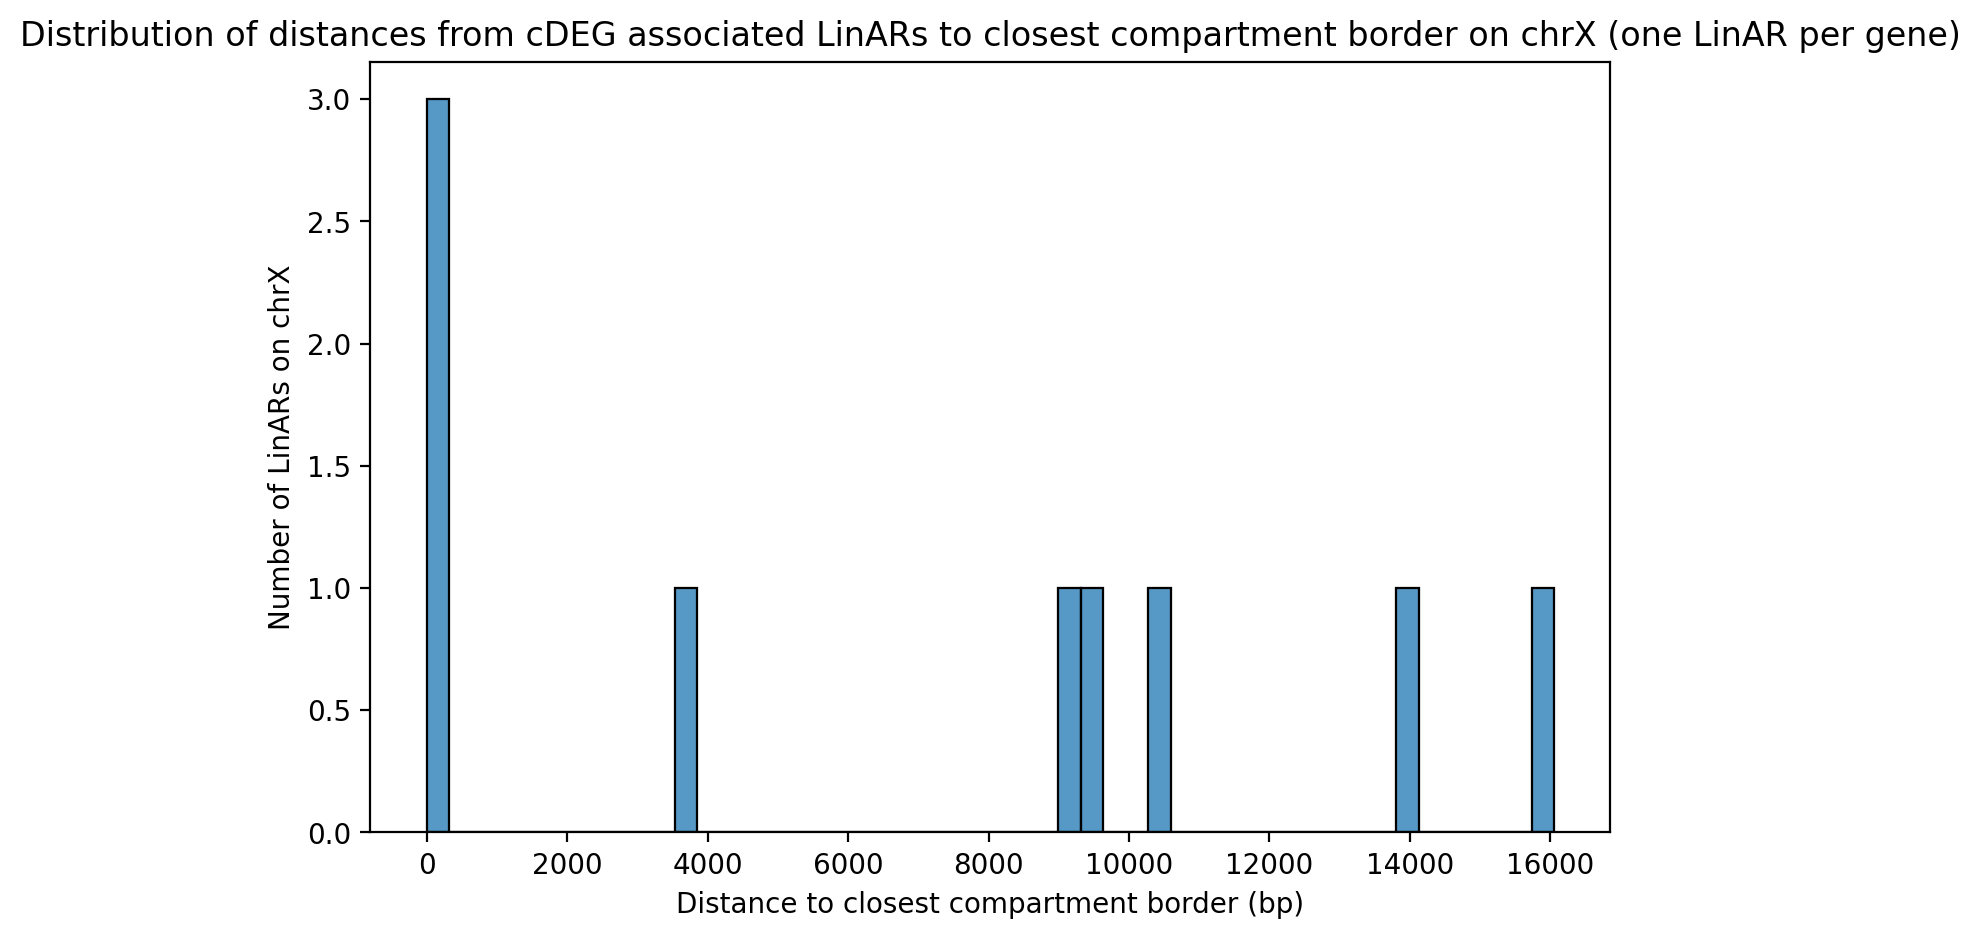

In [ ]:
# For each LinAR, find all compartments on the same chromosome, calculate the distance between that LinAR and each compartment, pick row with smallest distance, and store that in a new dataframe

# Keep only LinARs on chromosome X
ape_LinARs_chrX = ape_LinARs_df[ape_LinARs_df["Chr"] == "chrX"].copy()

# Keep only compartmetns on chromosome X
compartment_chrX = compartment_df[compartment_df["chrom"] == "chrX"].copy()

# Filter ape_LinARs_chrX to only contain LinARs associated with cDEG_human genes 
gene_list = GeneListCollection( "../data/cecilie_gen_lister.yaml") 
cDEG_human = gene_list.get('cDEG_human') 
linars_cDEG_df = ape_LinARs_chrX[ape_LinARs_chrX["Gene_name"].isin(cDEG_human)] 


results = []

for i, LinAR in linars_cDEG_df.iterrows():
    chrom = str(LinAR['Chr'])
    LinAR_start = LinAR['Start']
    LinAR_end = LinAR['End']

    # Find the compartment containing the LinAR
    containing_compartment = compartment_chrX[
        (LinAR_start >= compartment_chrX['start']) & 
        (LinAR_end <= compartment_chrX['end'])
    ]

    if not containing_compartment.empty:
        # LinAR fully contained: calculate absolute distance to nearest border
        compartment = containing_compartment.iloc[0]
        dist_to_start = abs(LinAR_start - compartment["start"])
        dist_to_end = abs(LinAR_end - compartment["end"])
        distance_to_border = min(dist_to_start, dist_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]
    else:
        # LinAR overlaps borders or outside compartments
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan

    
    results.append({
        'Gene_name': LinAR['Gene_name'],
        'LinAR_ID': LinAR['LinAR_ID'],
        'Chr': chrom,
        'Start_LinAR': LinAR_start,
        'End_LinAR': LinAR_end,
        'Lineage_name': LinAR.get('Lineage_name'),
        'Gene_name': LinAR['Gene_name'],
        'Compartment':  compartment_type,
        'Compartment_start': compartment_start,
        'Compartment_end': compartment_end,
        'Distance_to_compartment_border': distance_to_border
    })


linar_compartment_border_distances = pd.DataFrame(results)

# Keep only the LinAR with the shortest distance per gene
linar_closest_per_gene = (
    linar_compartment_border_distances
    .sort_values("Distance_to_compartment_border")
    .drop_duplicates(subset="Gene_name", keep="first")
)

print(linar_closest_per_gene.head())


# Plot distribution of absolute distances
plt.figure(figsize=(8,5))
sns.histplot(
    data=linar_closest_per_gene, 
    x='Distance_to_compartment_border', 
    bins=50, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Number of LinARs on chrX")
plt.title("Distribution of distances from cDEG associated LinARs to closest compartment border on chrX (one LinAR per gene)")
plt.show()




### How close to borders are cDEG genes (associated with LinAR vs not associated with LinAR)

  Gene_name   Chr  Gene_start  Gene_end Compartment  Compartment_start  \
0     AKAP4  chrX    50190776  50201007     Overlap                NaN   
1     BRWD3  chrX    80669502  80809877     Overlap                NaN   
2    CFAP47  chrX    35919733  36385317     Overlap                NaN   
3     DDX3X  chrX    41333307  41364472     Overlap                NaN   
4    DIAPH2  chrX    96684841  97604997     Overlap                NaN   

   Compartment_end  Distance_to_compartment_border  
0              NaN                               0  
1              NaN                               0  
2              NaN                               0  
3              NaN                               0  
4              NaN                               0  


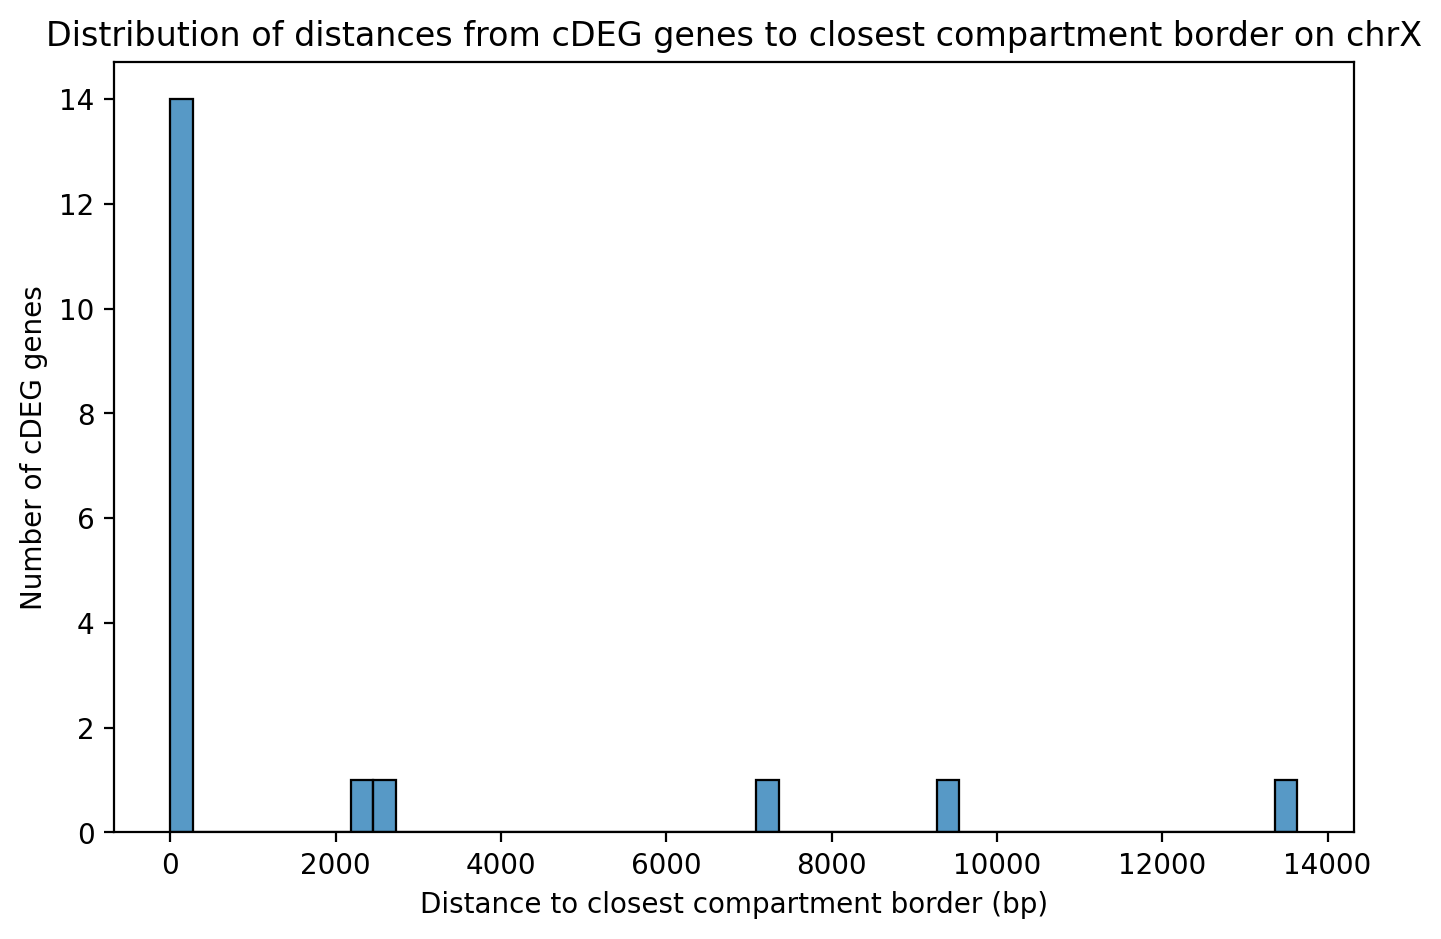

In [ ]:

###### All cDEG genes #######


# Get gene coordiantes
gene_coords_cDEG = gene_coords(cDEG_human, assembly="hg38")

gene_coords_cDEG_df = pd.DataFrame(
    gene_coords_cDEG,
    columns=["Chr", "Gene_start", "Gene_end", "Gene_name"]
)
# Make sure it only contain chrX genes
gene_coords_cDEG_df = gene_coords_cDEG_df[gene_coords_cDEG_df["Chr"] == "chrX"]


# Compute distances

gene_results = []

for i, gene in gene_coords_cDEG_df.iterrows():

    chrom = str(gene['Chr'])
    gene_start = gene['Gene_start']
    gene_end = gene['Gene_end']

    containing_compartment = compartment_chrX[
        (gene_start >= compartment_chrX['start']) &
        (gene_end   <= compartment_chrX['end'])
    ]

# compartment_start ... gene_start,    gene_end ... compartment_end

    if not containing_compartment.empty:
        compartment = containing_compartment.iloc[0]
        dist_start = abs(gene_start - compartment['start'])
        dist_end   = abs(gene_end   - compartment['end'])
        distance_to_border = min(dist_start, dist_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]

    else:
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan

    gene_results.append({
        "Gene_name": gene["Gene_name"],
        "Chr": chrom,
        "Gene_start": gene_start,
        "Gene_end": gene_end,
        "Compartment": compartment_type,
        "Compartment_start": compartment_start,
        "Compartment_end": compartment_end,
        "Distance_to_compartment_border": distance_to_border
    })

gene_compartment_distances = pd.DataFrame(gene_results)
print(gene_compartment_distances.head())

# Plot distances
plt.figure(figsize=(8,5))
sns.histplot(
    data=gene_compartment_distances, 
    x='Distance_to_compartment_border', 
    bins=50, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Number of cDEG genes")
plt.title("Distribution of distances from cDEG genes to closest compartment border on chrX")
plt.show()

cDEG genes with LinARs: 9
cDEG genes without LinARs: 10
Total: 19


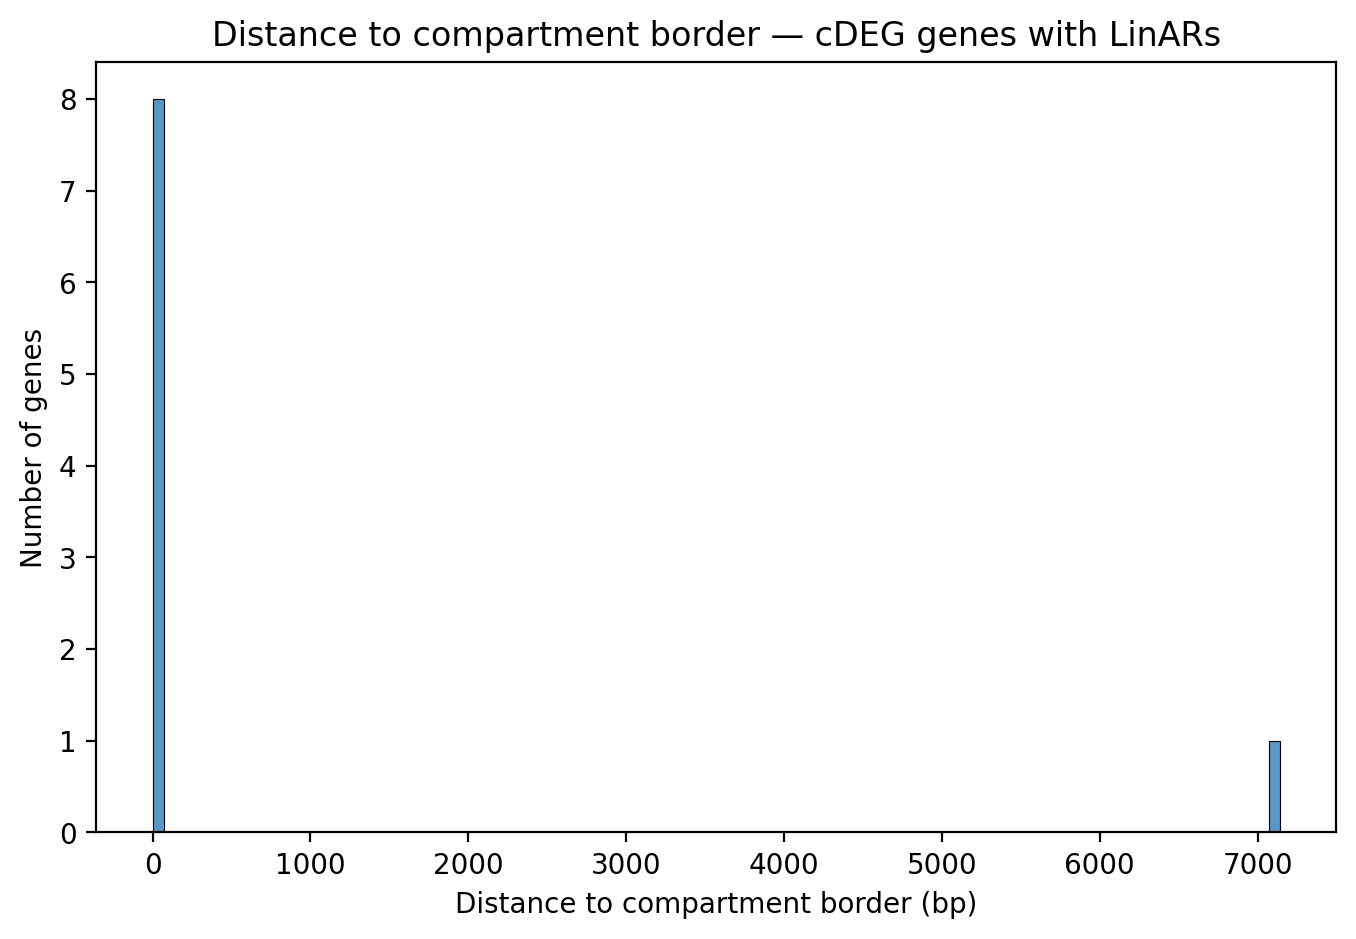

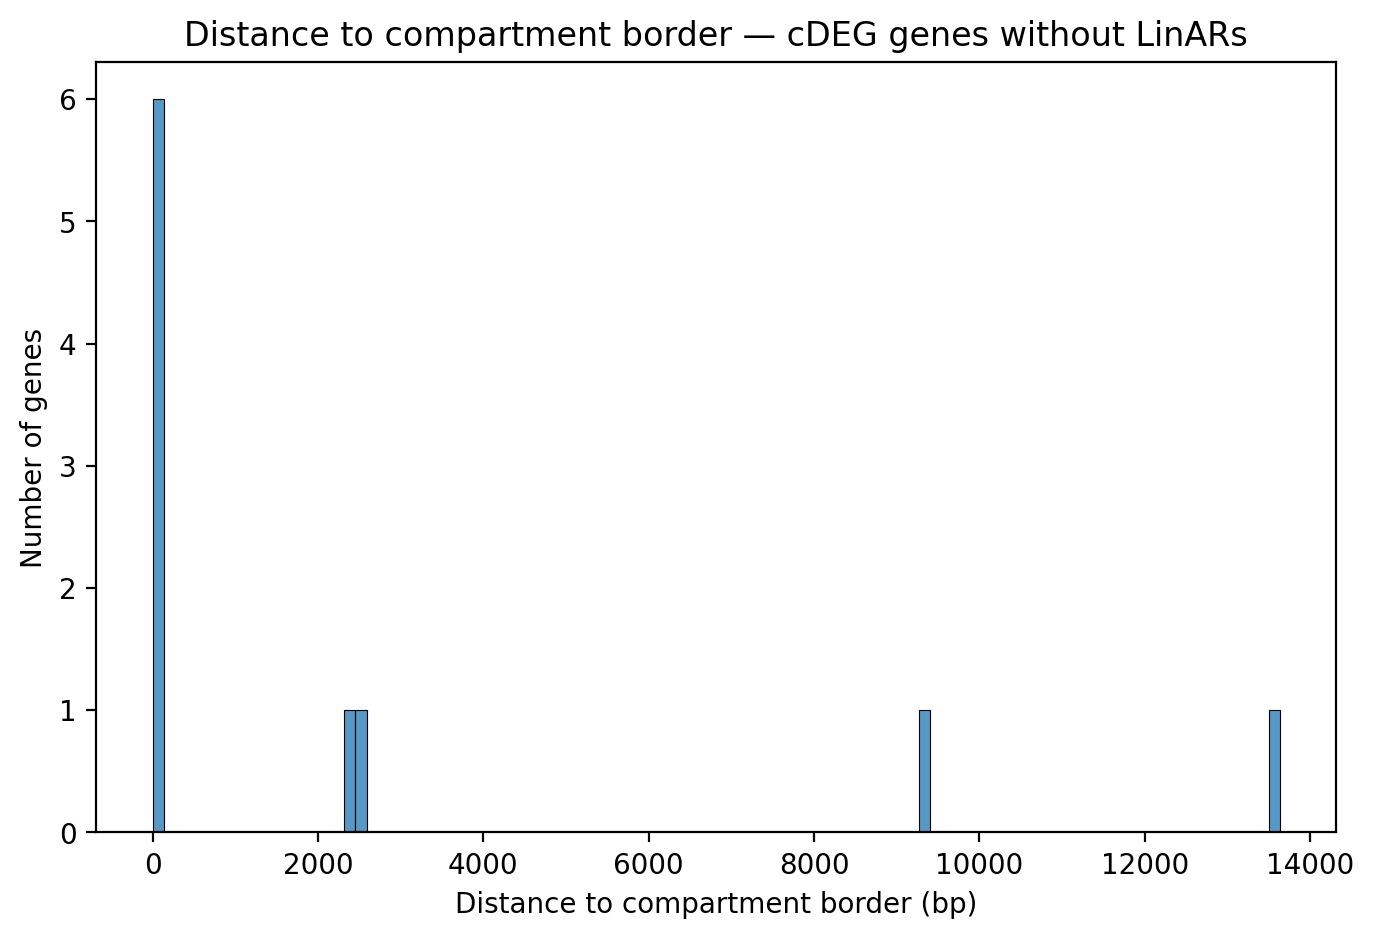

In [ ]:
### cDEG associated with a LinAR vs no associated with LinAR ####

cDEG_with_LinARs_list = set(linars_cDEG_df["Gene_name"].unique())

# Split gene_compartment_distances into two groups 
cDEG_with_LinARs_distances = gene_compartment_distances[
    gene_compartment_distances["Gene_name"].isin(cDEG_with_LinARs_list)
]
cDEG_without_LinARs_distances = gene_compartment_distances[
    ~gene_compartment_distances["Gene_name"].isin(cDEG_with_LinARs_list)
]

# Check sizez
print("cDEG genes with LinARs:", len(cDEG_with_LinARs_distances))
print("cDEG genes without LinARs:", len(cDEG_without_LinARs_distances))
print("Total:", len(gene_compartment_distances))



# Plot 1 — cDEG genes with LinARs 
plt.figure(figsize=(8,5))
sns.histplot(
    cDEG_with_LinARs_distances["Distance_to_compartment_border"],
    bins=100, 
    edgecolor='black'
)
plt.xlabel("Distance to compartment border (bp)")
plt.ylabel("Number of genes")
plt.title("Distance to compartment border — cDEG genes with LinARs")
plt.show()


# Plot 2 — cDEG genes without LinARs 
plt.figure(figsize=(8,5))
sns.histplot(
    cDEG_without_LinARs_distances["Distance_to_compartment_border"],
    bins=100, 
    edgecolor='black'
)
plt.xlabel("Distance to compartment border (bp)")
plt.ylabel("Number of genes")
plt.title("Distance to compartment border — cDEG genes without LinARs")
plt.show()

In [ ]:
gene_compartment_distances

,Gene_name,Chr,Gene_start,Gene_end,Compartment,Compartment_start,Compartment_end,Distance_to_compartment_border
0,AKAP4,chrX,50190776,50201007,Overlap,NaN,NaN,0
1,BRWD3,chrX,80669502,80809877,Overlap,NaN,NaN,0
2,CFAP47,chrX,35919733,36385317,Overlap,NaN,NaN,0
3,DDX3X,chrX,41333307,41364472,Overlap,NaN,NaN,0
4,DIAPH2,chrX,96684841,97604997,Overlap,NaN,NaN,0
5,DYNLT3,chrX,37838835,37847571,A,37800000.0,37850000.0,2429
6,EDA,chrX,69616112,70039472,Overlap,NaN,NaN,0
7,FHL1,chrX,136146701,136211359,Overlap,NaN,NaN,0
8,FTSJ1,chrX,48476198,48486364,A,48450000.0,48500000.0,13636
9,HDX,chrX,84317877,84502453,Overlap,NaN,NaN,0
